# Self-Serve Kiosks Sales Analysis – Addition Technologies Pvt Ltd

**Analysis Period:** October 2025 – December 2025  
**Clients (Restaurants):** Veena Stores | Rameshwaram Cafe | Bigbyte | Asha Sweets  
**Location:** Bangalore  

This notebook contains:
- **Dashboard 1** – Individual restaurant food-item-level sales analysis
- **Dashboard 2** – Company-level monthly sales comparison & customer footfall across all 4 clients


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Global style
plt.rcParams.update({
    'figure.facecolor': '#F7F9FC',
    'axes.facecolor': '#FFFFFF',
    'axes.edgecolor': '#CCCCCC',
    'axes.grid': True,
    'grid.color': '#EEEEEE',
    'grid.linestyle': '--',
    'font.family': 'DejaVu Sans',
    'font.size': 11
})

BRAND_COLORS = ['#1F6FEB', '#2EA043', '#F78166', '#D2A8FF']
REST_COLORS = {
    'Veena Stores':     '#1F6FEB',
    'Rameshwaram Cafe': '#2EA043',
    'Bigbyte':          '#F78166',
    'Asha Sweets':      '#D2A8FF'
}
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
df = pd.read_csv('Self_Serve_Kiosks_Sales_Data.csv', parse_dates=['Date', 'Order_DateTime'])

# Ensure correct dtypes
df['Month'] = pd.Categorical(df['Month'],
    categories=['October 2025', 'November 2025', 'December 2025'], ordered=True)

print(f'Dataset shape: {df.shape}')
print(f'Date range: {df["Date"].min().date()} → {df["Date"].max().date()}')
df.head()

Dataset shape: (93100, 21)
Date range: 2025-10-01 → 2025-12-31


,Transaction_ID,Date,Month,Month_Num,Year,Day_of_Week,Order_DateTime,Restaurant,Kiosk_ID,Customer_ID,...,Category,Unit_Price,Quantity,Total_Sales,Discount,Net_Sales,Payment_Mode,City,Is_Weekend,Is_Festival_Day
0,TXN-000001,2025-10-01,October 2025,10,2025,Wednesday,2025-10-01 12:52:00,Veena Stores,KIOSK-VEE-03,CUST-VEE-20251001-0001,...,Beverages,20,1,20,0.0,20.0,UPI,Bangalore,False,False
1,TXN-000002,2025-10-01,October 2025,10,2025,Wednesday,2025-10-01 12:52:00,Veena Stores,KIOSK-VEE-03,CUST-VEE-20251001-0001,...,Beverages,30,1,30,0.0,30.0,UPI,Bangalore,False,False
2,TXN-000003,2025-10-01,October 2025,10,2025,Wednesday,2025-10-01 12:52:00,Veena Stores,KIOSK-VEE-03,CUST-VEE-20251001-0001,...,South Indian,45,1,45,0.0,45.0,UPI,Bangalore,False,False
3,TXN-000004,2025-10-01,October 2025,10,2025,Wednesday,2025-10-01 11:48:00,Veena Stores,KIOSK-VEE-02,CUST-VEE-20251001-0002,...,South Indian,45,1,45,0.0,45.0,UPI,Bangalore,False,False
4,TXN-000005,2025-10-01,October 2025,10,2025,Wednesday,2025-10-01 17:50:00,Veena Stores,KIOSK-VEE-03,CUST-VEE-20251001-0003,...,Combos,95,1,95,0.0,95.0,UPI,Bangalore,False,False


In [3]:
print('=== Data Quality Check ===')
print(f'Total transactions : {len(df):,}')
print(f'Null values        :\n{df.isnull().sum()}')
print(f'Duplicate rows     : {df.duplicated().sum()}')
print(f'\nRestaurants        : {df["Restaurant"].nunique()} → {list(df["Restaurant"].unique())}')
print(f'Months             : {list(df["Month"].unique())}')
print(f'Kiosk IDs          : {df["Kiosk_ID"].nunique()}')
print(f'Unique Food Items  : {df["Food_Item"].nunique()}')
print(f'\nTotal Net Sales    : ₹{df["Net_Sales"].sum():,.2f}')
print(f'Total Footfall     : {df["Customer_ID"].nunique():,} unique customers')

=== Data Quality Check ===
Total transactions : 93,100
Null values        :
Transaction_ID     0
Date               0
Month              0
Month_Num          0
Year               0
Day_of_Week        0
Order_DateTime     0
Restaurant         0
Kiosk_ID           0
Customer_ID        0
Food_Item          0
Category           0
Unit_Price         0
Quantity           0
Total_Sales        0
Discount           0
Net_Sales          0
Payment_Mode       0
City               0
Is_Weekend         0
Is_Festival_Day    0
dtype: int64
Duplicate rows     : 0

Restaurants        : 4 → ['Veena Stores', 'Rameshwaram Cafe', 'Bigbyte', 'Asha Sweets']
Months             : ['October 2025', 'November 2025', 'December 2025']
Kiosk IDs          : 12
Unique Food Items  : 59

Total Net Sales    : ₹9,018,569.75
Total Footfall     : 54,766 unique customers


---
## Key Performance Indicators (KPIs)


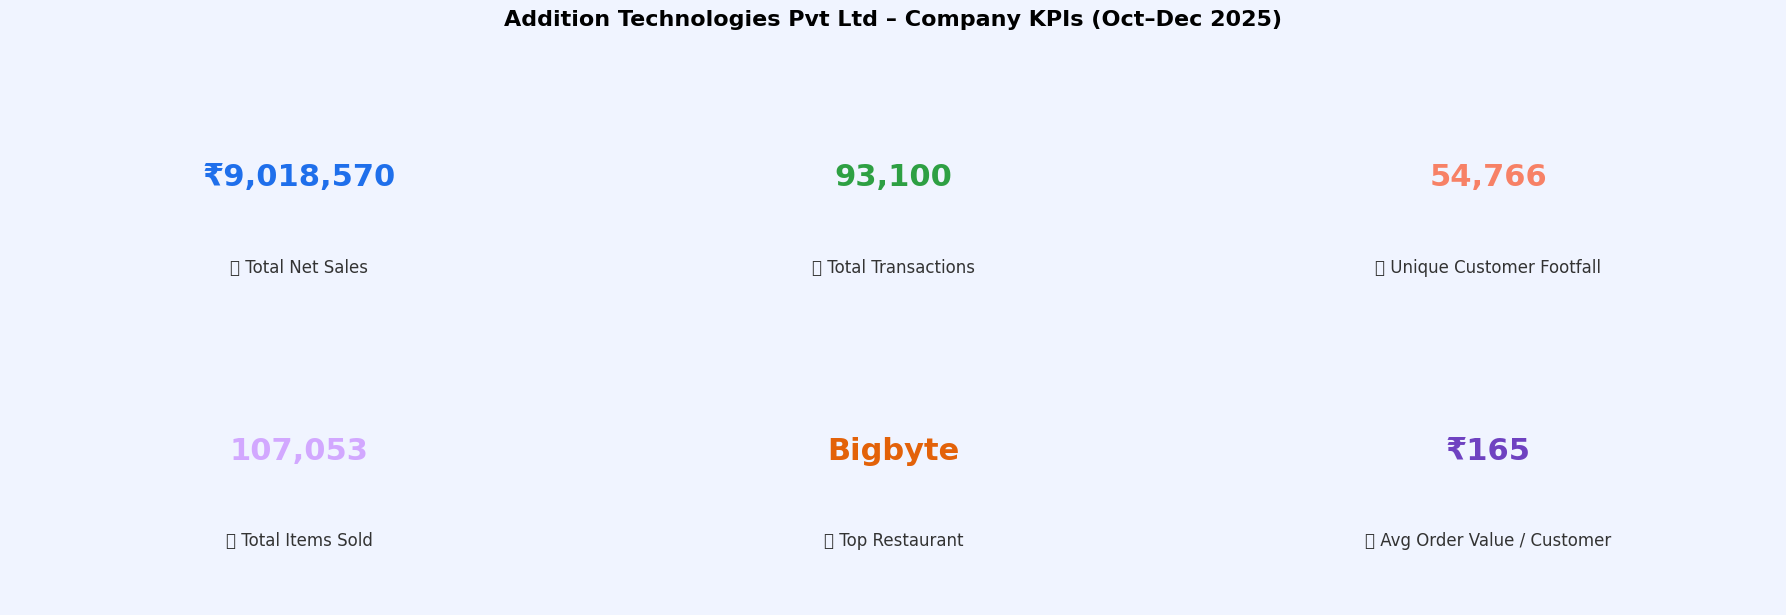

KPI card saved.


In [4]:
total_sales    = df['Net_Sales'].sum()
total_txn      = len(df)
unique_cust    = df['Customer_ID'].nunique()
avg_order_val  = df.groupby('Customer_ID')['Net_Sales'].sum().mean()
total_qty      = df['Quantity'].sum()
top_restaurant = df.groupby('Restaurant')['Net_Sales'].sum().idxmax()

kpi_data = {
    '💰 Total Net Sales': f'₹{total_sales:,.0f}',
    '🧾 Total Transactions': f'{total_txn:,}',
    '👣 Unique Customer Footfall': f'{unique_cust:,}',
    '📦 Total Items Sold': f'{total_qty:,}',
    '🏆 Top Restaurant': top_restaurant,
    '💳 Avg Order Value / Customer': f'₹{avg_order_val:,.0f}'
}

fig, axes = plt.subplots(2, 3, figsize=(18, 6))
fig.suptitle('Addition Technologies Pvt Ltd – Company KPIs (Oct–Dec 2025)',
             fontsize=16, fontweight='bold', y=1.02)
fig.patch.set_facecolor('#F0F4FF')

colors = ['#1F6FEB', '#2EA043', '#F78166', '#D2A8FF', '#E36209', '#6F42C1']
for ax, (kpi, val), clr in zip(axes.flat, kpi_data.items(), colors):
    ax.set_facecolor(clr + '22')
    ax.text(0.5, 0.6, val, ha='center', va='center', fontsize=22,
            fontweight='bold', color=clr, transform=ax.transAxes)
    ax.text(0.5, 0.25, kpi, ha='center', va='center', fontsize=12,
            color='#333333', transform=ax.transAxes)
    ax.axis('off')

plt.tight_layout()
plt.savefig('kpi_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('KPI card saved.')

---
# 📊 Dashboard 1 – Individual Restaurant Sales Analysis
> Food-item level sales for each of the 4 client restaurants  
> Time Period: October 2025 – December 2025


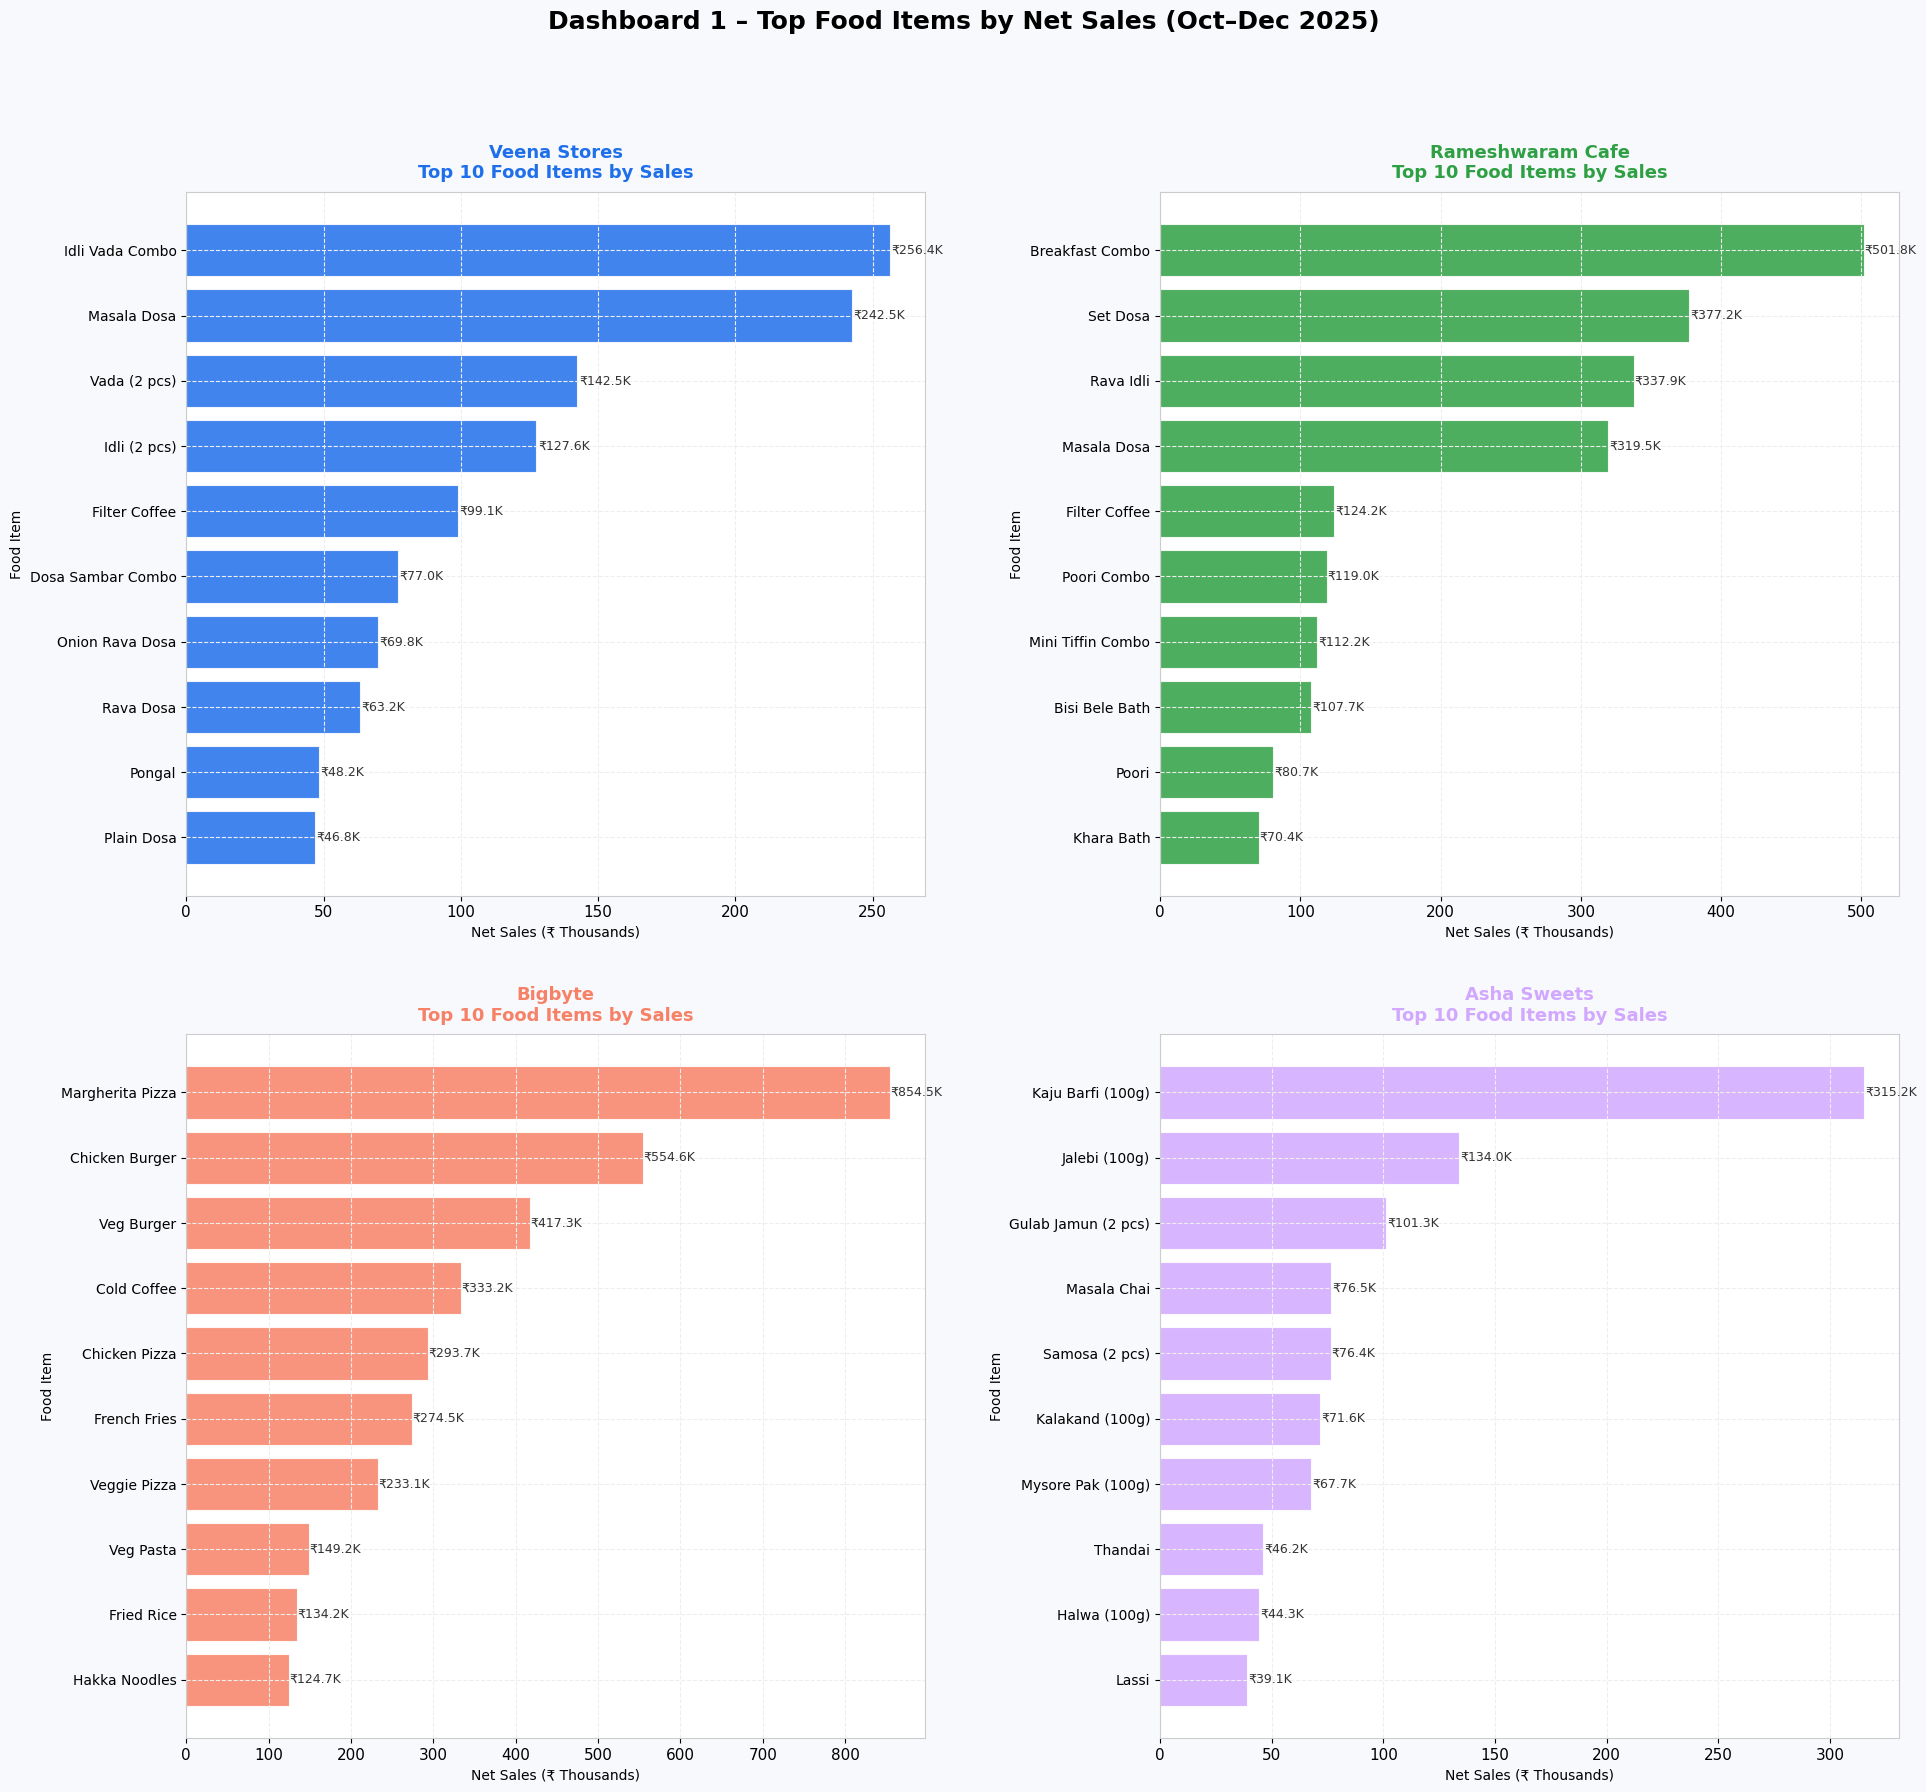

Dashboard 1 – Top Items chart saved.


In [5]:
restaurants = ['Veena Stores', 'Rameshwaram Cafe', 'Bigbyte', 'Asha Sweets']

fig, axes = plt.subplots(2, 2, figsize=(20, 18))
fig.suptitle('Dashboard 1 – Top Food Items by Net Sales (Oct–Dec 2025)',
             fontsize=18, fontweight='bold', y=1.01)
fig.patch.set_facecolor('#F7F9FC')

for ax, rest in zip(axes.flat, restaurants):
    rdf = df[df['Restaurant'] == rest]
    item_sales = (rdf.groupby('Food_Item')['Net_Sales']
                    .sum()
                    .sort_values(ascending=True)
                    .tail(10))
    color = REST_COLORS[rest]
    bars = ax.barh(item_sales.index, item_sales.values / 1000, color=color, alpha=0.85,
                  edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, item_sales.values):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f'₹{val/1000:.1f}K', va='center', fontsize=9, color='#333333')
    ax.set_title(f'{rest}\nTop 10 Food Items by Sales',
                 fontsize=13, fontweight='bold', color=color, pad=10)
    ax.set_xlabel('Net Sales (₹ Thousands)', fontsize=10)
    ax.set_ylabel('Food Item', fontsize=10)
    ax.tick_params(axis='y', labelsize=10)

plt.tight_layout(pad=3.0)
plt.savefig('dashboard1_top_items.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard 1 – Top Items chart saved.')

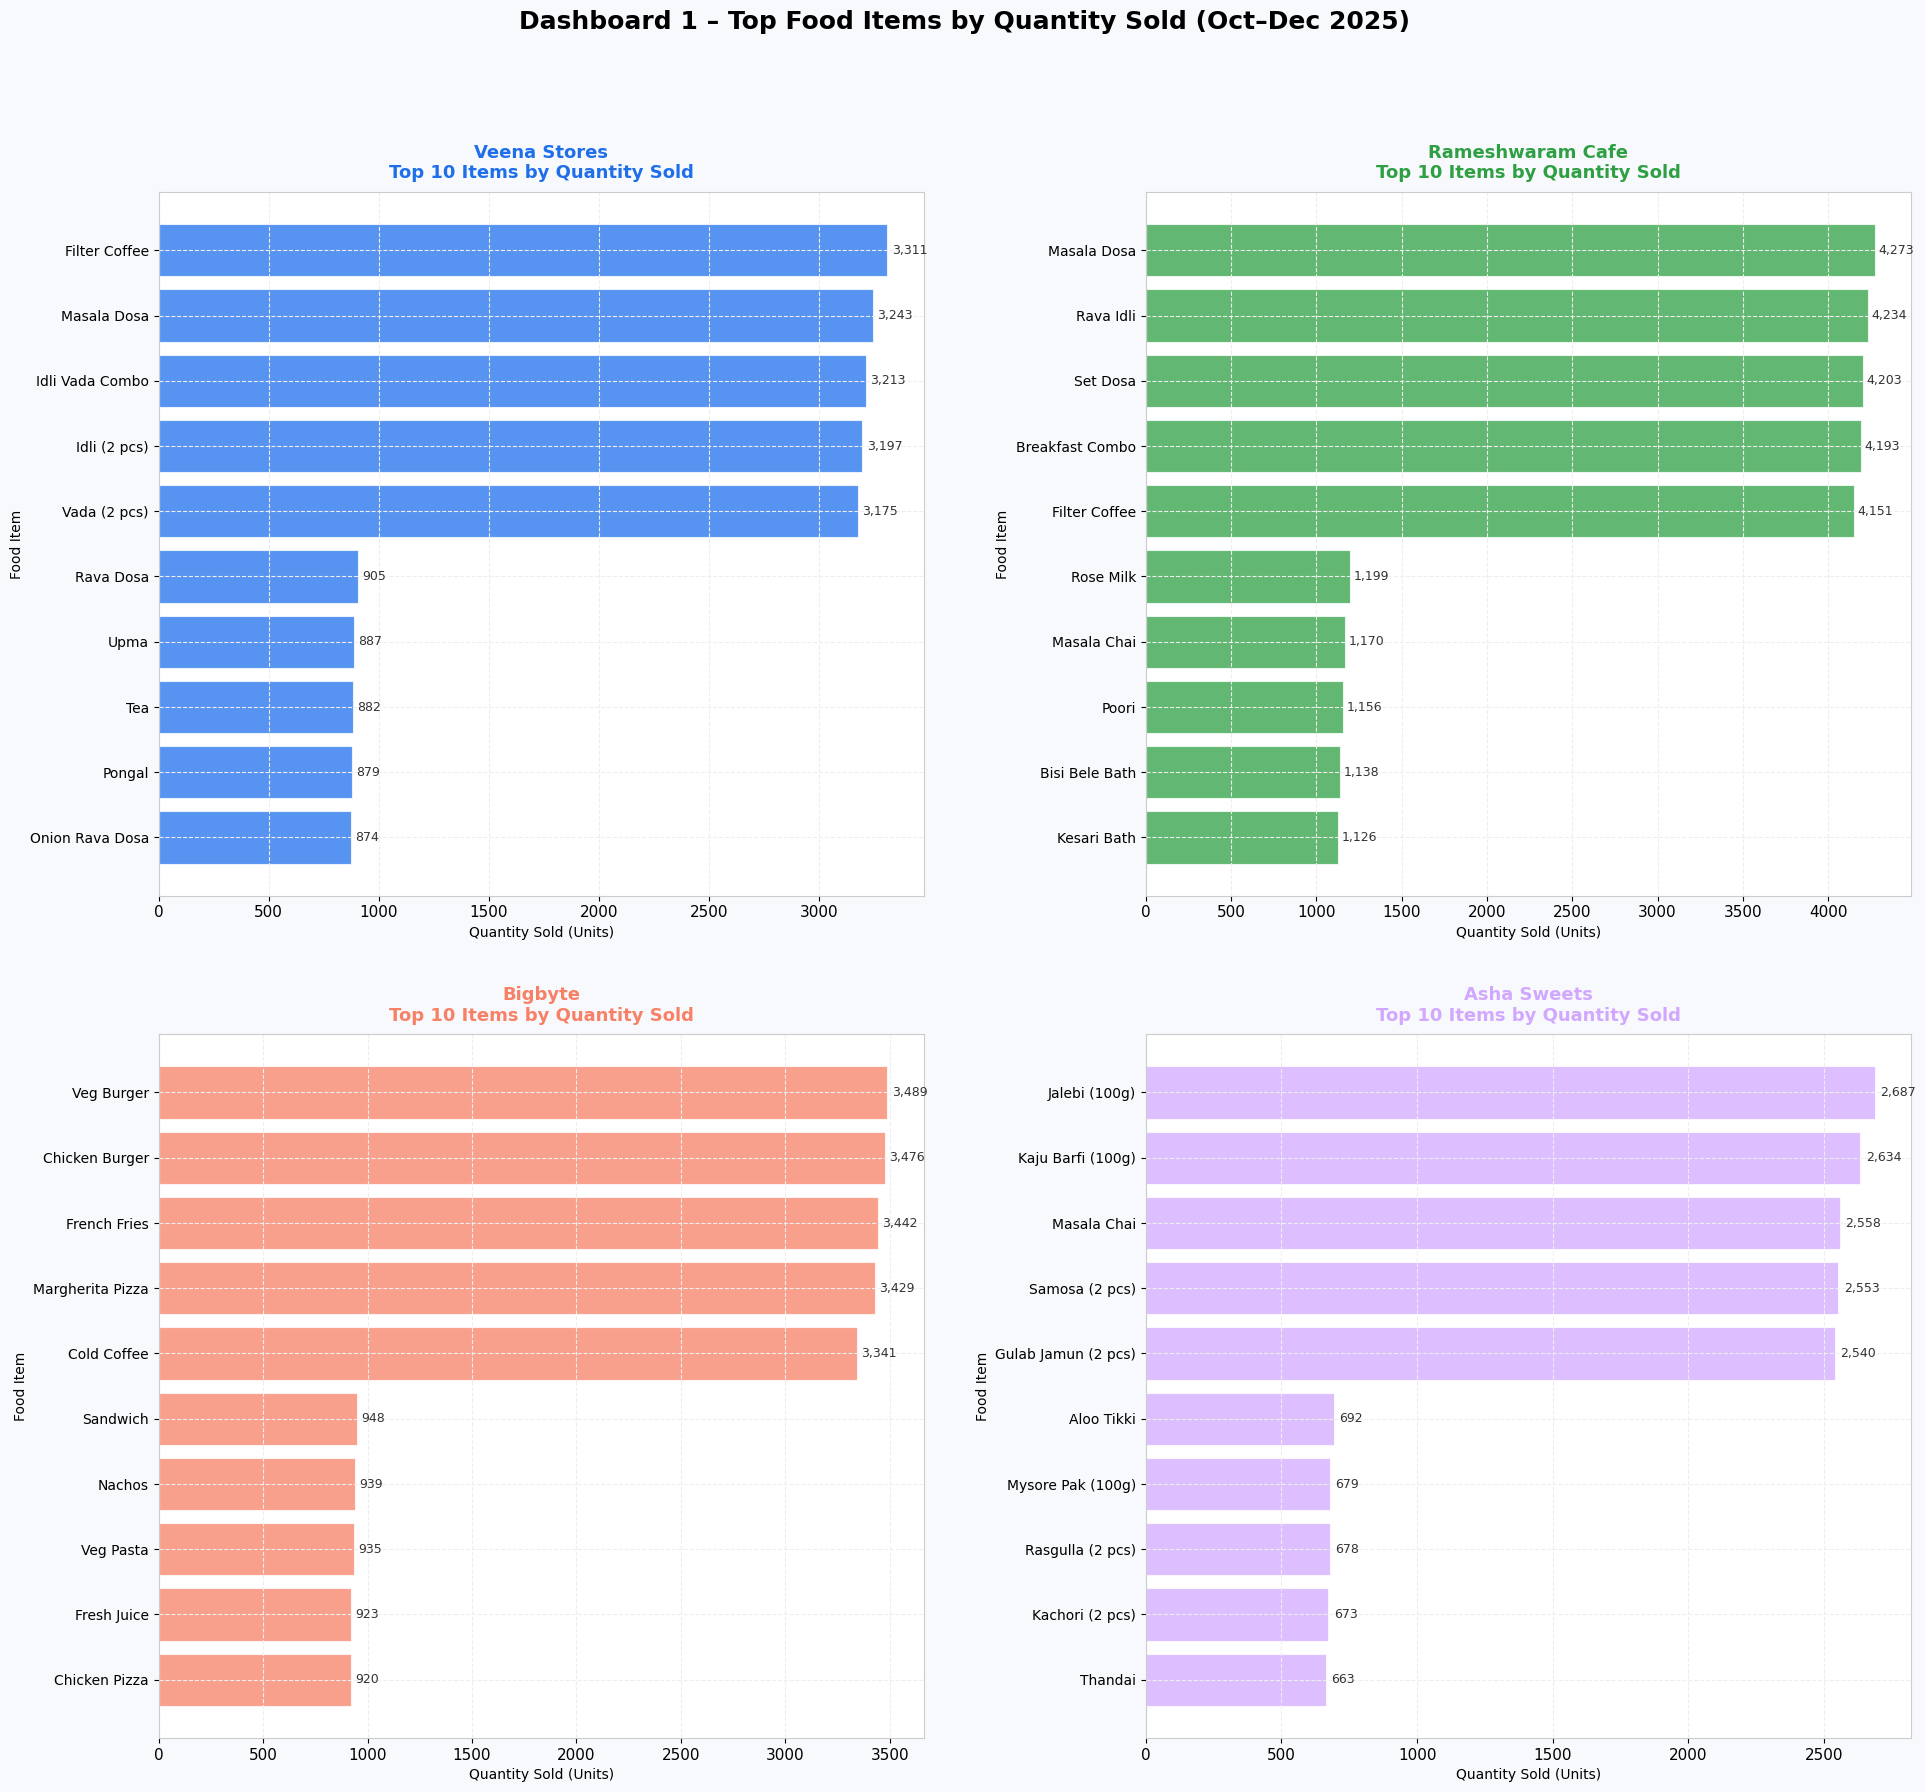

Dashboard 1 – Quantity chart saved.


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(20, 18))
fig.suptitle('Dashboard 1 – Top Food Items by Quantity Sold (Oct–Dec 2025)',
             fontsize=18, fontweight='bold', y=1.01)
fig.patch.set_facecolor('#F7F9FC')

for ax, rest in zip(axes.flat, restaurants):
    rdf = df[df['Restaurant'] == rest]
    item_qty = (rdf.groupby('Food_Item')['Quantity']
                   .sum()
                   .sort_values(ascending=True)
                   .tail(10))
    color = REST_COLORS[rest]
    bars = ax.barh(item_qty.index, item_qty.values, color=color, alpha=0.75,
                  edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, item_qty.values):
        ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
                f'{val:,}', va='center', fontsize=9, color='#333333')
    ax.set_title(f'{rest}\nTop 10 Items by Quantity Sold',
                 fontsize=13, fontweight='bold', color=color, pad=10)
    ax.set_xlabel('Quantity Sold (Units)', fontsize=10)
    ax.set_ylabel('Food Item', fontsize=10)
    ax.tick_params(axis='y', labelsize=10)

plt.tight_layout(pad=3.0)
plt.savefig('dashboard1_top_qty.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard 1 – Quantity chart saved.')

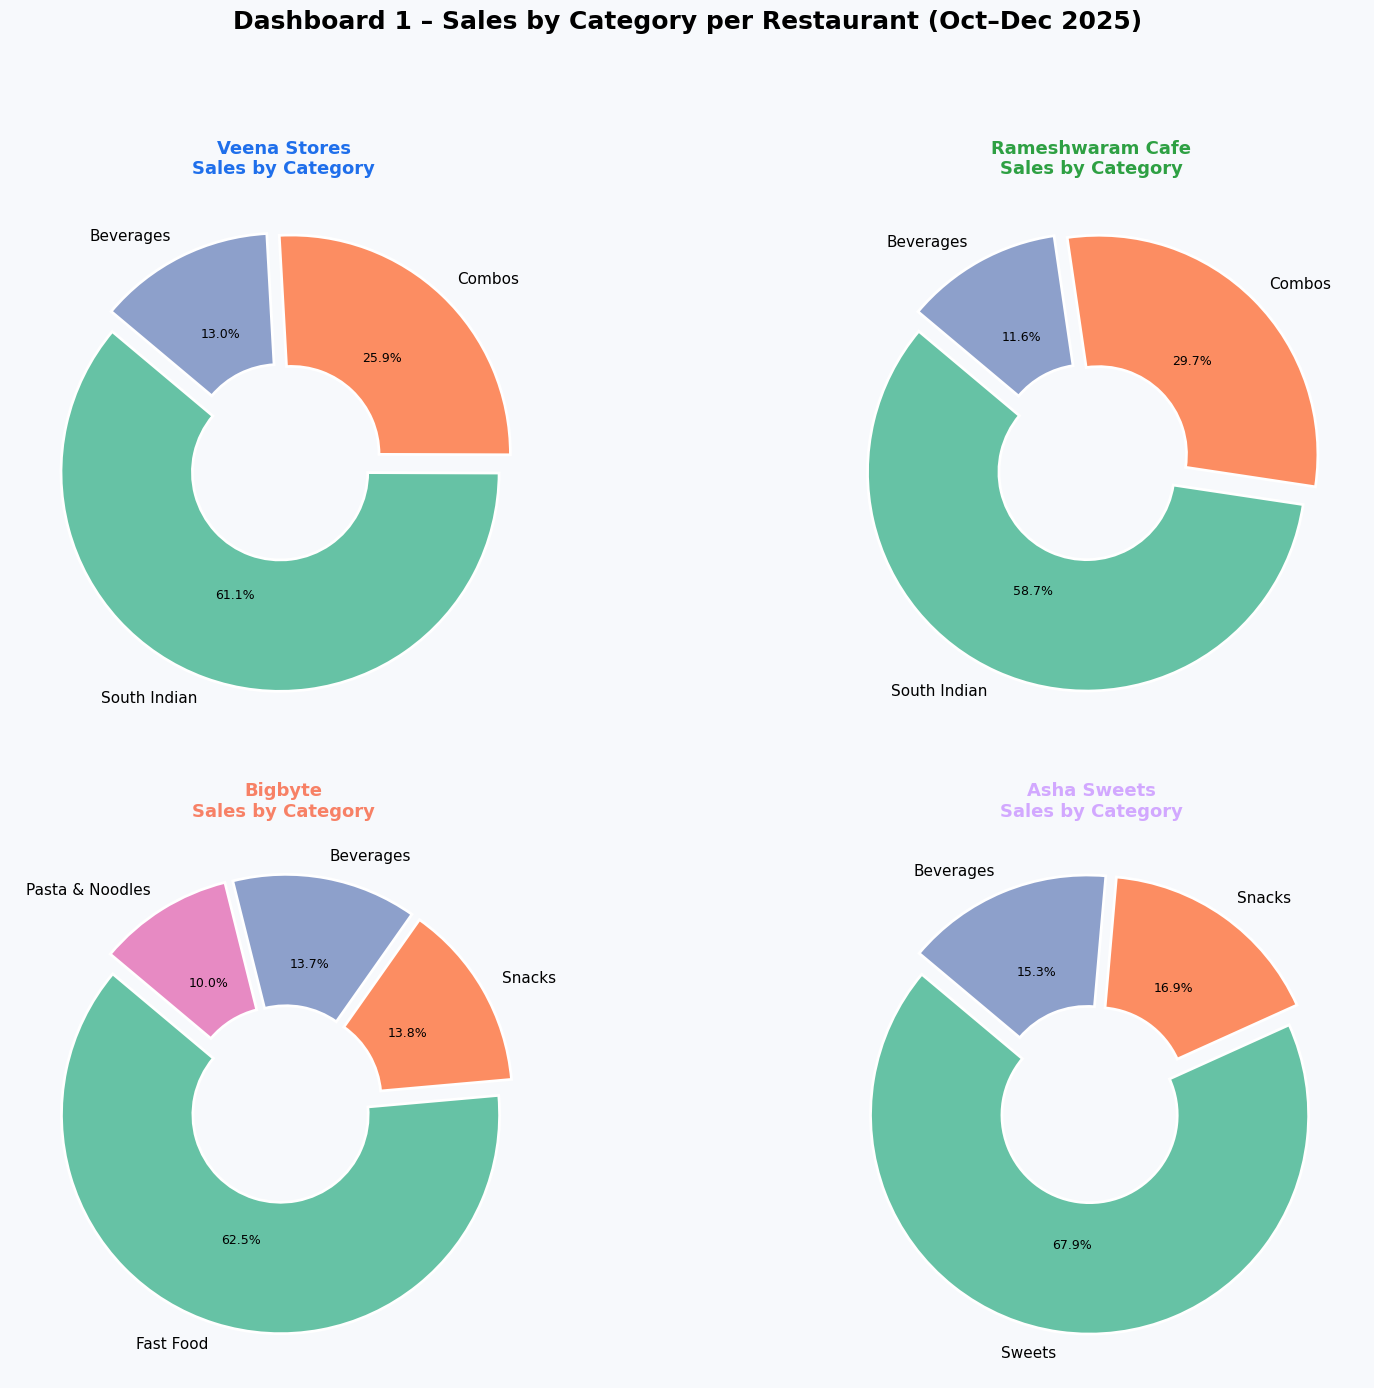

Dashboard 1 – Category pie chart saved.


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Dashboard 1 – Sales by Category per Restaurant (Oct–Dec 2025)',
             fontsize=18, fontweight='bold', y=1.01)
fig.patch.set_facecolor('#F7F9FC')

for ax, rest in zip(axes.flat, restaurants):
    rdf = df[df['Restaurant'] == rest]
    cat_sales = rdf.groupby('Category')['Net_Sales'].sum().sort_values(ascending=False)
    explode = [0.05] * len(cat_sales)
    wedge_props = dict(width=0.6, edgecolor='white', linewidth=2)
    wedges, texts, autotexts = ax.pie(
        cat_sales.values,
        labels=cat_sales.index,
        autopct='%1.1f%%',
        explode=explode,
        startangle=140,
        wedgeprops=wedge_props,
        colors=sns.color_palette('Set2', len(cat_sales))
    )
    for text in autotexts:
        text.set_fontsize(9)
    ax.set_title(f'{rest}\nSales by Category',
                 fontsize=13, fontweight='bold', color=REST_COLORS[rest], pad=10)

plt.tight_layout(pad=3.0)
plt.savefig('dashboard1_category_pie.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard 1 – Category pie chart saved.')

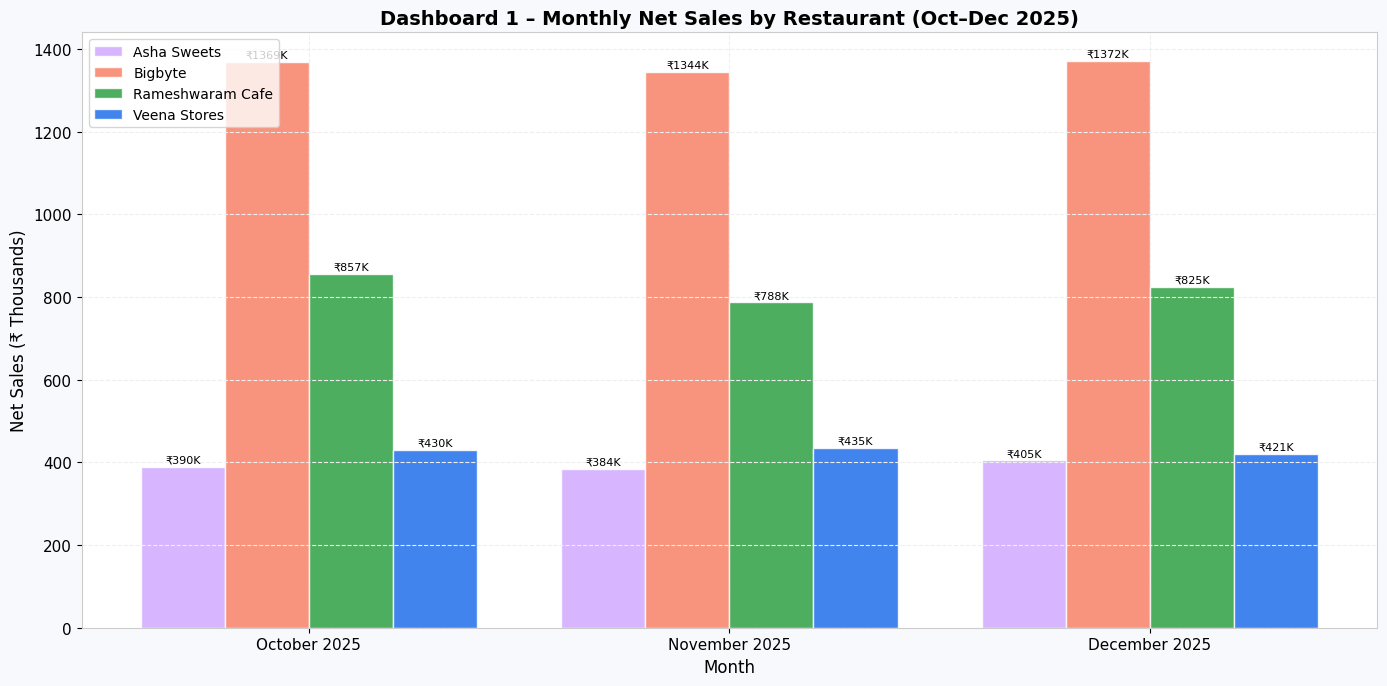

Dashboard 1 – Monthly grouped bar chart saved.


In [8]:
monthly_rest = (df.groupby(['Restaurant', 'Month'])['Net_Sales']
                  .sum()
                  .reset_index())
pivot_monthly = monthly_rest.pivot(index='Month', columns='Restaurant', values='Net_Sales')

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#F7F9FC')
x = np.arange(len(pivot_monthly.index))
width = 0.2
offsets = [-1.5, -0.5, 0.5, 1.5]
for i, (col, offset) in enumerate(zip(pivot_monthly.columns, offsets)):
    bars = ax.bar(x + offset * width, pivot_monthly[col] / 1000,
                  width=width, label=col, color=REST_COLORS[col], alpha=0.85,
                  edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 5,
                f'₹{bar.get_height():.0f}K',
                ha='center', va='bottom', fontsize=8, rotation=0)

ax.set_title('Dashboard 1 – Monthly Net Sales by Restaurant (Oct–Dec 2025)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Net Sales (₹ Thousands)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(['October 2025', 'November 2025', 'December 2025'], fontsize=11)
ax.legend(fontsize=10, loc='upper left')
plt.tight_layout()
plt.savefig('dashboard1_monthly_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard 1 – Monthly grouped bar chart saved.')

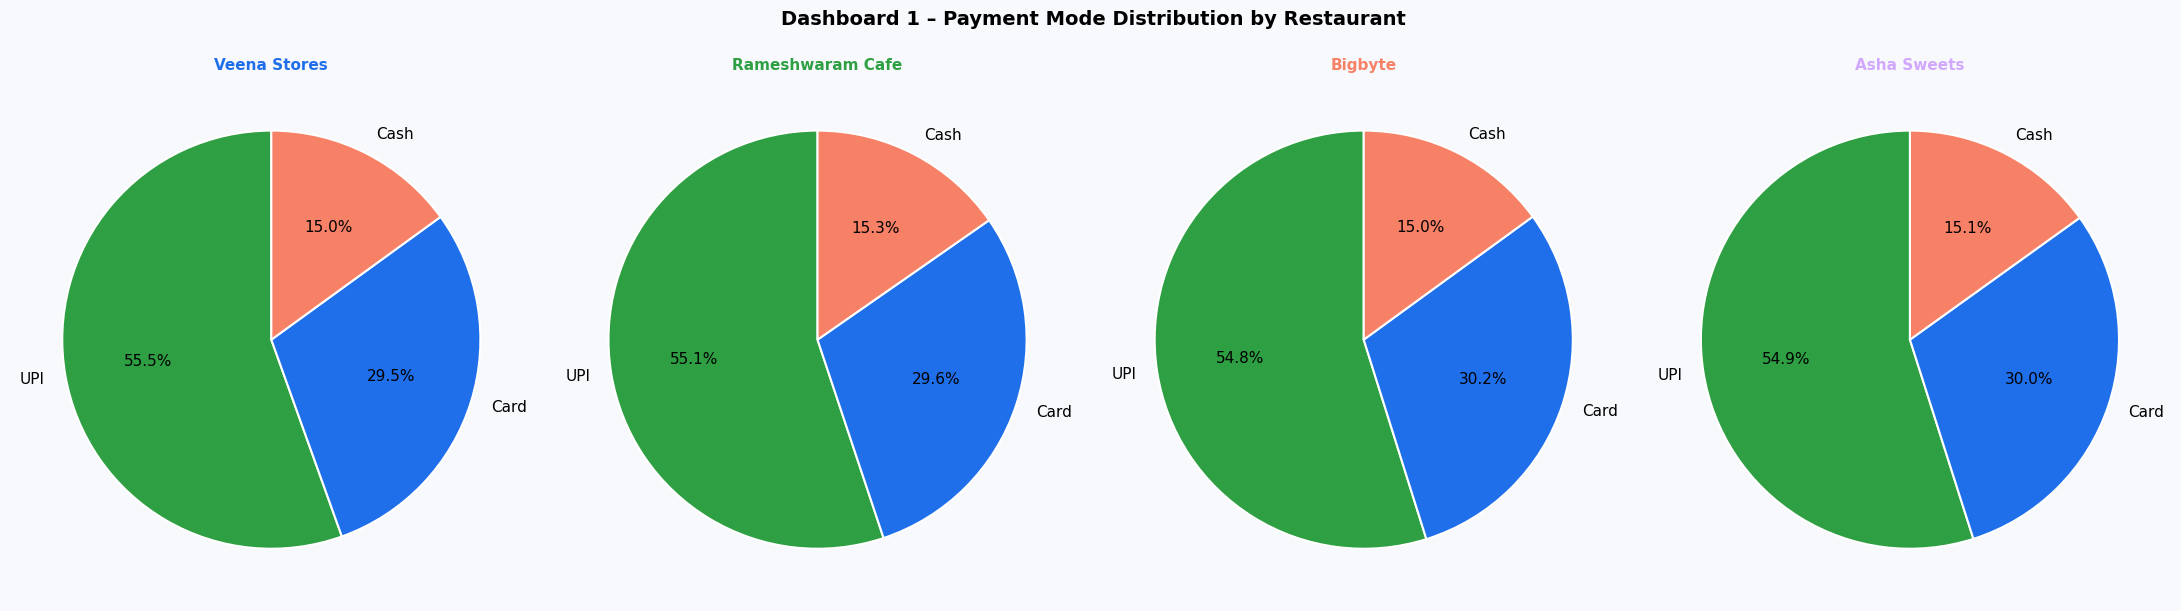

Dashboard 1 – Payment mode chart saved.


In [9]:
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle('Dashboard 1 – Payment Mode Distribution by Restaurant',
             fontsize=14, fontweight='bold', y=1.02)
fig.patch.set_facecolor('#F7F9FC')

for ax, rest in zip(axes, restaurants):
    rdf = df[df['Restaurant'] == rest]
    pay_counts = rdf['Payment_Mode'].value_counts()
    ax.pie(pay_counts.values, labels=pay_counts.index,
           autopct='%1.1f%%', startangle=90,
           colors=['#2EA043', '#1F6FEB', '#F78166'],
           wedgeprops=dict(edgecolor='white', linewidth=1.5))
    ax.set_title(rest, fontsize=11, fontweight='bold', color=REST_COLORS[rest])

plt.tight_layout()
plt.savefig('dashboard1_payment_mode.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard 1 – Payment mode chart saved.')

In [10]:
d1_kpis = []
for rest in restaurants:
    rdf = df[df['Restaurant'] == rest]
    d1_kpis.append({
        'Restaurant': rest,
        'Total Net Sales (₹)': f'{rdf["Net_Sales"].sum():,.0f}',
        'Total Transactions': f'{len(rdf):,}',
        'Unique Customers': f'{rdf["Customer_ID"].nunique():,}',
        'Top Selling Item': rdf.groupby("Food_Item")["Net_Sales"].sum().idxmax(),
        'Best Month': rdf.groupby("Month")["Net_Sales"].sum().idxmax()
    })

kpi_df = pd.DataFrame(d1_kpis)
print('\n=== Dashboard 1 – Restaurant KPI Summary ===')
print(kpi_df.to_string(index=False))


=== Dashboard 1 – Restaurant KPI Summary ===
      Restaurant Total Net Sales (₹) Total Transactions Unique Customers  Top Selling Item    Best Month
    Veena Stores           1,285,265             20,754           12,171   Idli Vada Combo November 2025
Rameshwaram Cafe           2,469,408             29,037           17,113   Breakfast Combo  October 2025
         Bigbyte           4,084,882             25,164           14,776  Margherita Pizza December 2025
     Asha Sweets           1,179,014             18,145           10,706 Kaju Barfi (100g) December 2025


---
# 📈 Dashboard 2 – Company-Level Sales Comparison & Customer Footfall
> Sales trends for Addition Technologies Pvt Ltd across all 4 client restaurants  
> Time Period: October 2025 – December 2025


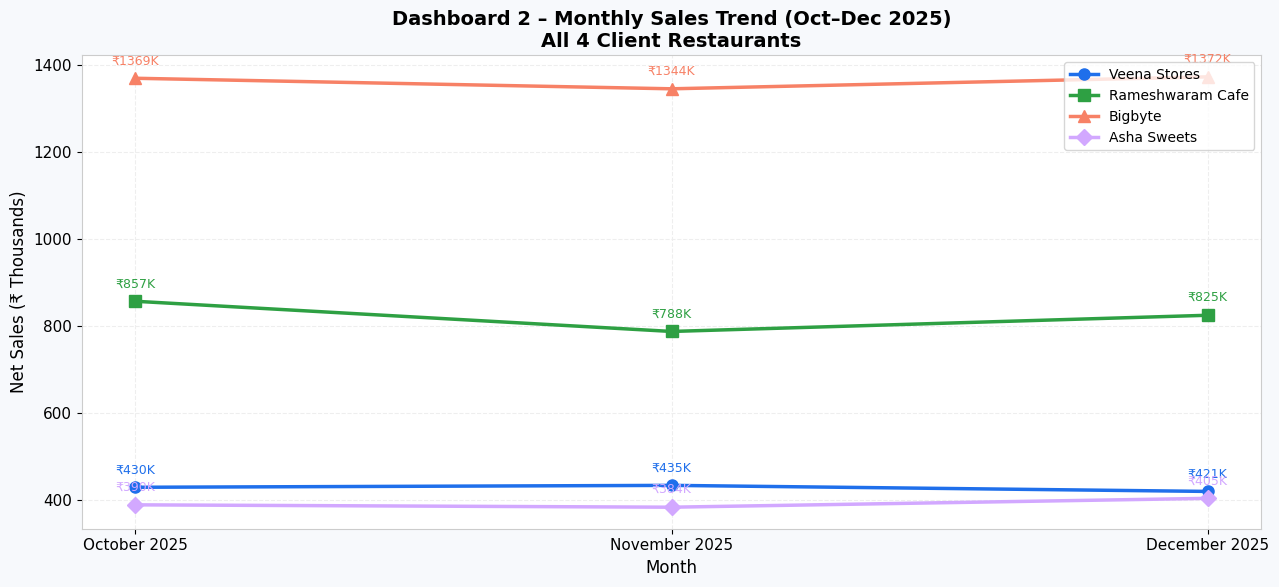

Dashboard 2 – Monthly trend line saved.


In [11]:
# Monthly trend line for all 4 restaurants
monthly_pivot = (df.groupby(['Month', 'Restaurant'])['Net_Sales']
                   .sum().unstack('Restaurant') / 1000)

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#F7F9FC')
markers = ['o', 's', '^', 'D']
for rest, marker in zip(restaurants, markers):
    ax.plot(monthly_pivot.index.astype(str), monthly_pivot[rest],
            marker=marker, linewidth=2.5, markersize=8,
            color=REST_COLORS[rest], label=rest)
    for x, y in zip(range(len(monthly_pivot)), monthly_pivot[rest]):
        ax.annotate(f'₹{y:.0f}K', (x, y),
                    textcoords='offset points', xytext=(0, 10),
                    ha='center', fontsize=9, color=REST_COLORS[rest])

ax.set_title('Dashboard 2 – Monthly Sales Trend (Oct–Dec 2025)\nAll 4 Client Restaurants',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Net Sales (₹ Thousands)', fontsize=12)
ax.legend(fontsize=10)
ax.set_xticklabels(['October 2025', 'November 2025', 'December 2025'], fontsize=11)
plt.tight_layout()
plt.savefig('dashboard2_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard 2 – Monthly trend line saved.')

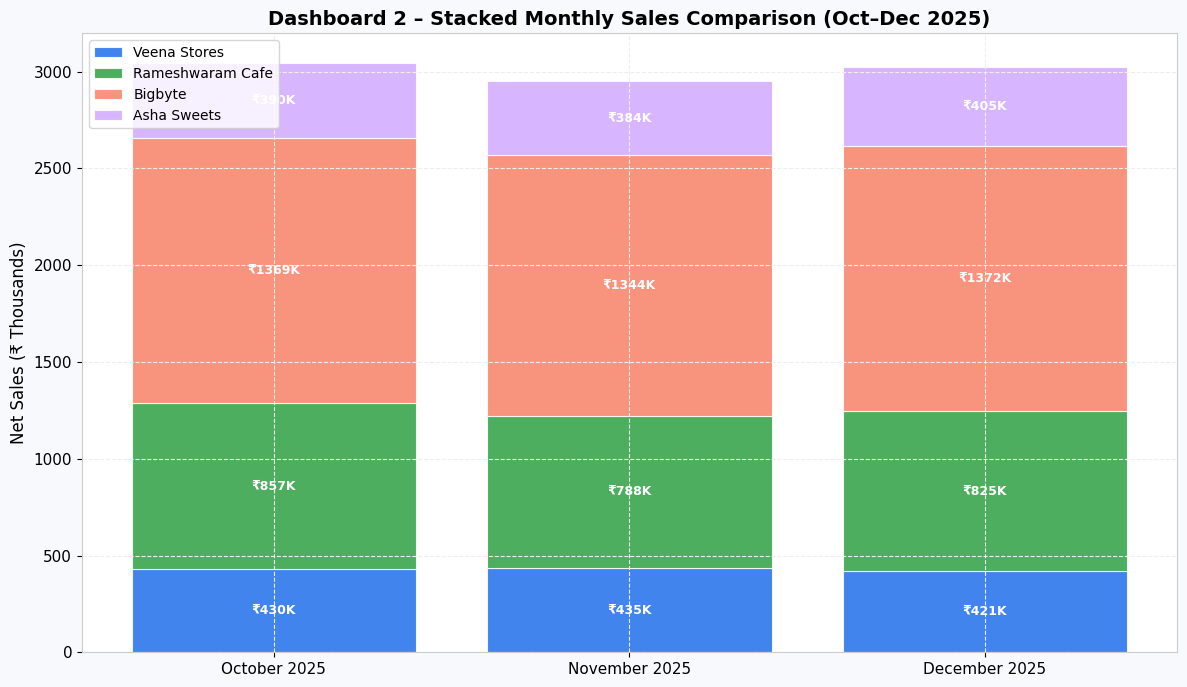

Dashboard 2 – Stacked bar chart saved.


In [12]:
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#F7F9FC')
bottom = np.zeros(3)
months_labels = ['October 2025', 'November 2025', 'December 2025']
x = np.arange(3)
for rest in restaurants:
    vals = monthly_pivot[rest].values
    bars = ax.bar(x, vals, bottom=bottom, label=rest,
                  color=REST_COLORS[rest], alpha=0.85, edgecolor='white', linewidth=0.8)
    for xi, (b, v) in enumerate(zip(bottom, vals)):
        if v > 30:
            ax.text(xi, b + v / 2, f'₹{v:.0f}K', ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white')
    bottom += vals

ax.set_title('Dashboard 2 – Stacked Monthly Sales Comparison (Oct–Dec 2025)',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(months_labels, fontsize=11)
ax.set_ylabel('Net Sales (₹ Thousands)', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('dashboard2_stacked_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard 2 – Stacked bar chart saved.')

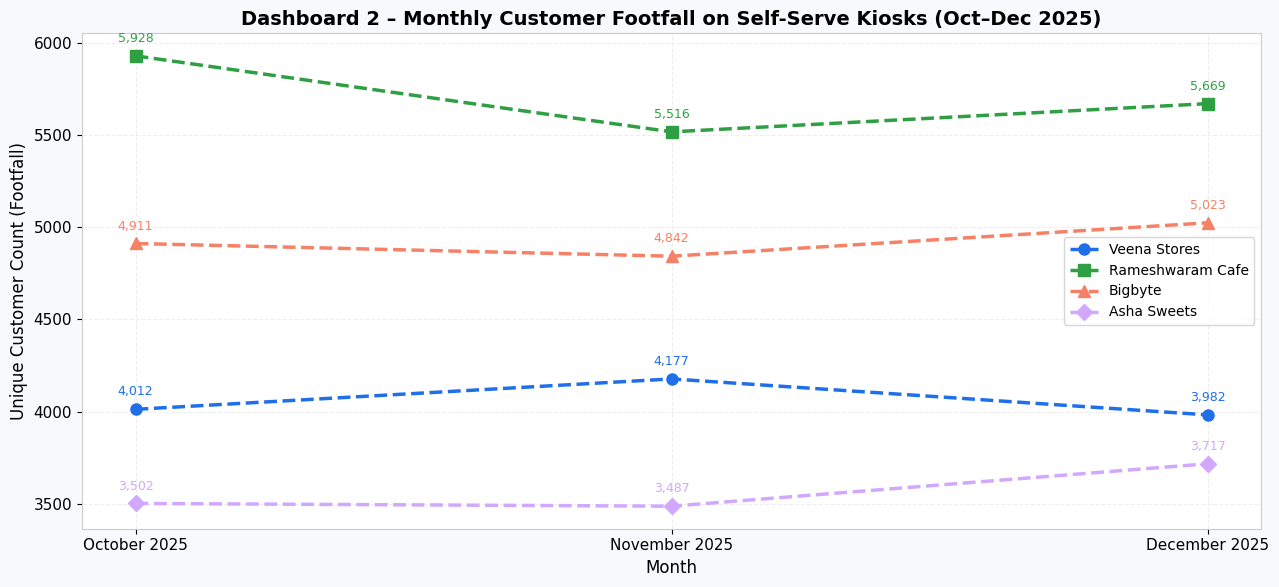

Dashboard 2 – Footfall trend saved.


In [13]:
# Footfall = unique Customer_IDs per restaurant per month
footfall = (df.groupby(['Month', 'Restaurant'])['Customer_ID']
              .nunique()
              .reset_index()
              .rename(columns={'Customer_ID': 'Footfall'}))
footfall_pivot = footfall.pivot(index='Month', columns='Restaurant', values='Footfall')

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#F7F9FC')
for rest, marker in zip(restaurants, markers):
    ax.plot(footfall_pivot.index.astype(str), footfall_pivot[rest],
            marker=marker, linewidth=2.5, markersize=8,
            color=REST_COLORS[rest], label=rest, linestyle='--')
    for x, y in zip(range(len(footfall_pivot)), footfall_pivot[rest]):
        ax.annotate(f'{y:,}', (x, y),
                    textcoords='offset points', xytext=(0, 10),
                    ha='center', fontsize=9, color=REST_COLORS[rest])

ax.set_title('Dashboard 2 – Monthly Customer Footfall on Self-Serve Kiosks (Oct–Dec 2025)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Unique Customer Count (Footfall)', fontsize=12)
ax.legend(fontsize=10)
ax.set_xticklabels(['October 2025', 'November 2025', 'December 2025'], fontsize=11)
plt.tight_layout()
plt.savefig('dashboard2_footfall_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard 2 – Footfall trend saved.')

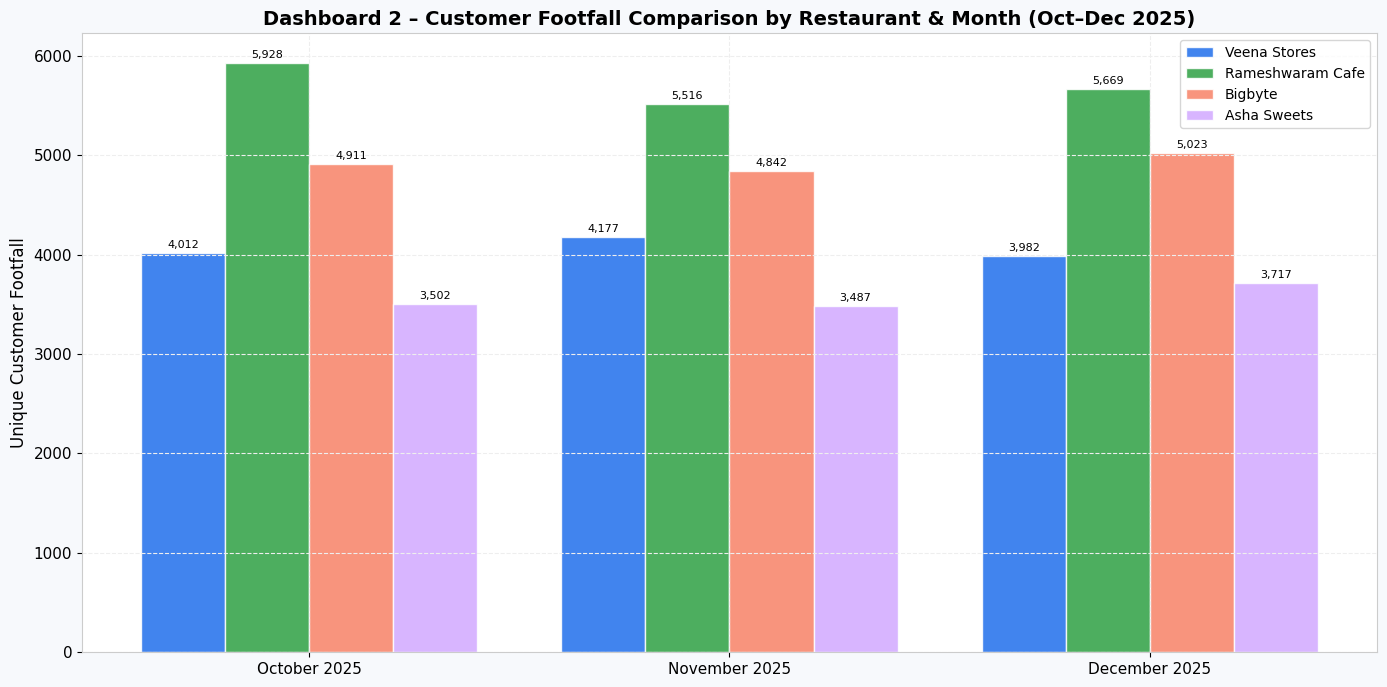

Dashboard 2 – Footfall grouped bar saved.


In [14]:
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#F7F9FC')
x = np.arange(len(footfall_pivot.index))
width = 0.2
offsets = [-1.5, -0.5, 0.5, 1.5]
for rest, offset in zip(restaurants, offsets):
    bars = ax.bar(x + offset * width, footfall_pivot[rest],
                  width=width, label=rest, color=REST_COLORS[rest],
                  alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 30,
                f'{int(bar.get_height()):,}',
                ha='center', va='bottom', fontsize=8)

ax.set_title('Dashboard 2 – Customer Footfall Comparison by Restaurant & Month (Oct–Dec 2025)',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['October 2025', 'November 2025', 'December 2025'], fontsize=11)
ax.set_ylabel('Unique Customer Footfall', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('dashboard2_footfall_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard 2 – Footfall grouped bar saved.')

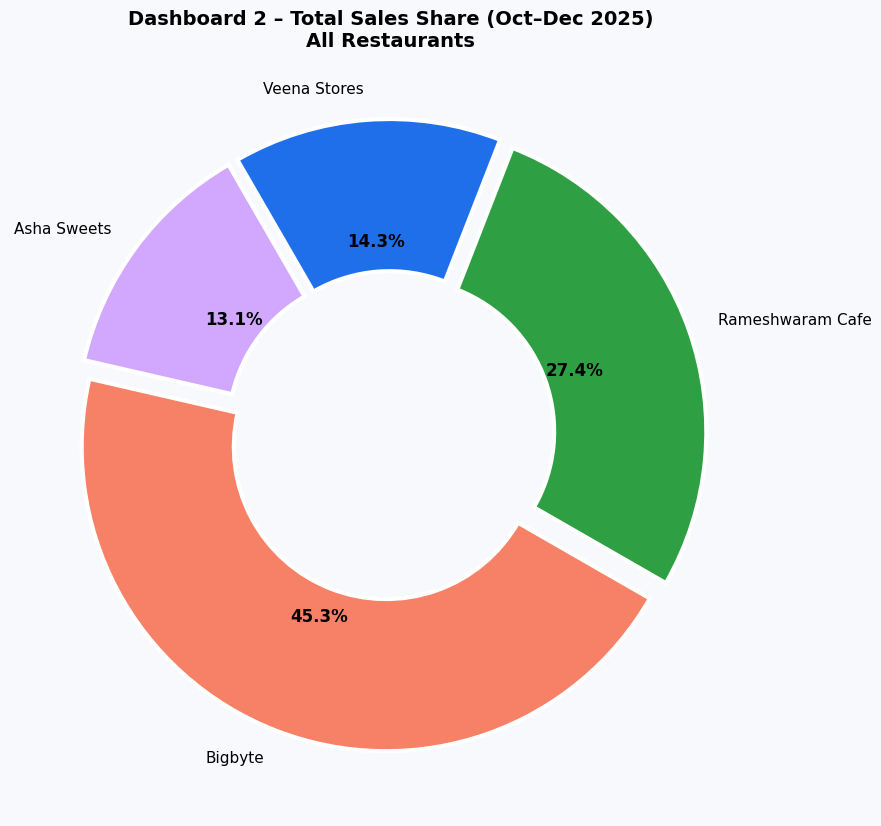

Dashboard 2 – Sales share donut saved.


In [15]:
total_by_rest = df.groupby('Restaurant')['Net_Sales'].sum()
fig, ax = plt.subplots(figsize=(9, 9))
fig.patch.set_facecolor('#F7F9FC')
wedge_props = dict(width=0.5, edgecolor='white', linewidth=3)
wedges, texts, autotexts = ax.pie(
    total_by_rest.values,
    labels=total_by_rest.index,
    autopct='%1.1f%%',
    startangle=120,
    colors=[REST_COLORS[r] for r in total_by_rest.index],
    wedgeprops=wedge_props,
    explode=[0.04] * 4
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
ax.set_title('Dashboard 2 – Total Sales Share (Oct–Dec 2025)\nAll Restaurants',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dashboard2_sales_share_donut.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard 2 – Sales share donut saved.')

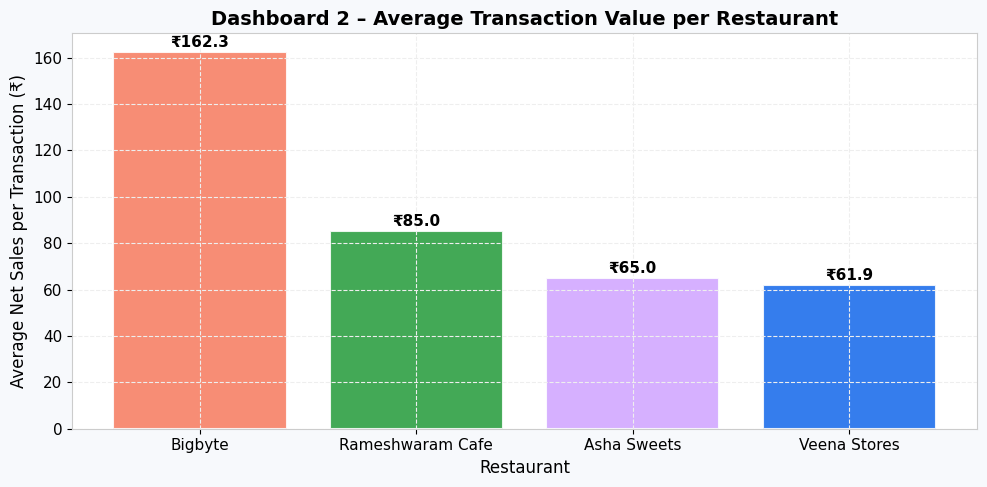

Dashboard 2 – Avg transaction value chart saved.


In [16]:
avg_txn = df.groupby('Restaurant')['Net_Sales'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#F7F9FC')
bars = ax.bar(avg_txn.index,
              avg_txn.values,
              color=[REST_COLORS[r] for r in avg_txn.index],
              edgecolor='white', linewidth=1.5, alpha=0.9)
for bar, val in zip(bars, avg_txn.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f'₹{val:.1f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Dashboard 2 – Average Transaction Value per Restaurant',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Average Net Sales per Transaction (₹)', fontsize=12)
ax.set_xlabel('Restaurant', fontsize=12)
plt.tight_layout()
plt.savefig('dashboard2_avg_txn_value.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard 2 – Avg transaction value chart saved.')

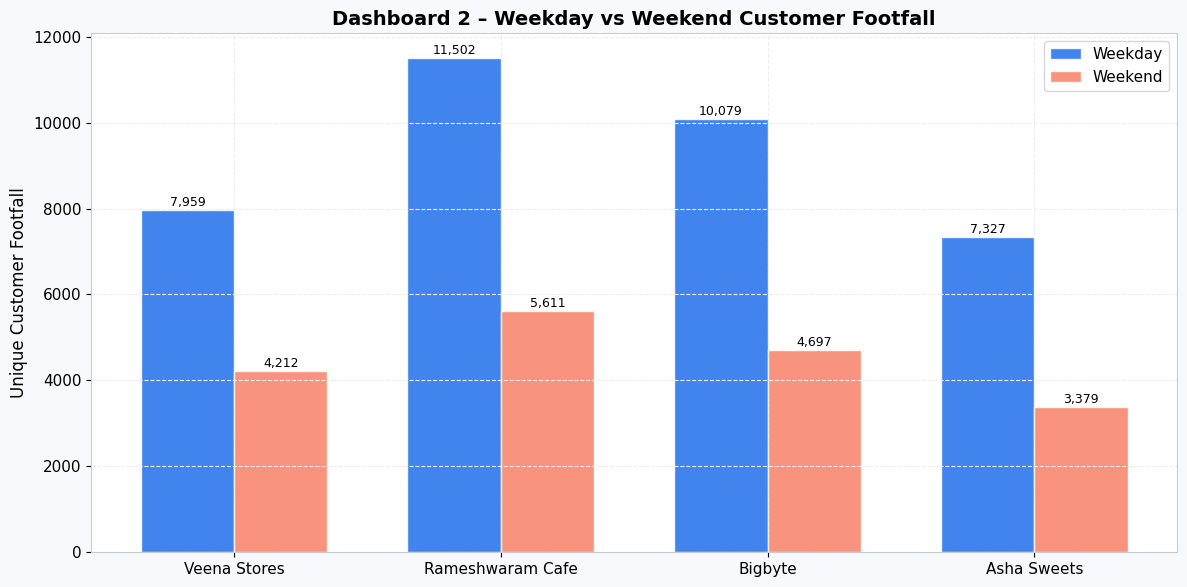

Dashboard 2 – Weekend vs weekday footfall saved.


In [17]:
wknd_footfall = (df.groupby(['Restaurant', 'Is_Weekend'])['Customer_ID']
                   .nunique()
                   .reset_index()
                   .rename(columns={'Customer_ID': 'Footfall'}))
wknd_footfall['Day_Type'] = wknd_footfall['Is_Weekend'].map({True: 'Weekend', False: 'Weekday'})

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#F7F9FC')
rest_list = list(restaurants)
x = np.arange(len(rest_list))
width = 0.35
for i, dtype in enumerate(['Weekday', 'Weekend']):
    vals = [wknd_footfall[(wknd_footfall['Restaurant'] == r) & (wknd_footfall['Day_Type'] == dtype)]['Footfall'].values[0]
            for r in rest_list]
    bars = ax.bar(x + (i - 0.5) * width, vals, width=width, label=dtype,
                  color='#1F6FEB' if dtype == 'Weekday' else '#F78166',
                  alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 30,
                f'{val:,}', ha='center', va='bottom', fontsize=9)

ax.set_title('Dashboard 2 – Weekday vs Weekend Customer Footfall',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(rest_list, fontsize=11)
ax.set_ylabel('Unique Customer Footfall', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('dashboard2_weekend_weekday.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard 2 – Weekend vs weekday footfall saved.')

In [18]:
print('\n=== Dashboard 2 – Company-Level KPI Summary ===')
summary = (df.groupby(['Restaurant', 'Month'])
             .agg(
                 Net_Sales=('Net_Sales', 'sum'),
                 Transactions=('Transaction_ID', 'count'),
                 Footfall=('Customer_ID', 'nunique')
             )
             .reset_index())
summary['Net_Sales'] = summary['Net_Sales'].map('₹{:,.0f}'.format)
print(summary.to_string(index=False))


=== Dashboard 2 – Company-Level KPI Summary ===
      Restaurant         Month  Net_Sales  Transactions  Footfall
     Asha Sweets  October 2025   ₹389,848          5914      3502
     Asha Sweets November 2025   ₹384,416          5931      3487
     Asha Sweets December 2025   ₹404,750          6300      3717
         Bigbyte  October 2025 ₹1,368,606          8396      4911
         Bigbyte November 2025 ₹1,344,428          8243      4842
         Bigbyte December 2025 ₹1,371,848          8525      5023
Rameshwaram Cafe  October 2025   ₹856,919         10062      5928
Rameshwaram Cafe November 2025   ₹787,661          9251      5516
Rameshwaram Cafe December 2025   ₹824,828          9724      5669
    Veena Stores  October 2025   ₹430,120          6858      4012
    Veena Stores November 2025   ₹434,521          7085      4177
    Veena Stores December 2025   ₹420,624          6811      3982


---
## Export Cleaned Dataset
The cleaned dataset below can be imported directly into **Power BI Desktop**.


In [19]:
# Export Power BI-ready CSV
powerbi_cols = [
    'Transaction_ID', 'Date', 'Month', 'Month_Num', 'Year', 'Day_of_Week',
    'Order_DateTime', 'Restaurant', 'Kiosk_ID', 'Customer_ID',
    'Food_Item', 'Category', 'Unit_Price', 'Quantity',
    'Total_Sales', 'Discount', 'Net_Sales', 'Payment_Mode',
    'City', 'Is_Weekend', 'Is_Festival_Day'
]
df[powerbi_cols].to_csv('Kiosks_Sales_PowerBI_Ready.csv', index=False)
print(f'Power BI ready CSV exported: {len(df):,} rows × {len(powerbi_cols)} columns')
print('File: Kiosks_Sales_PowerBI_Ready.csv')
print('\nColumn descriptions:')
col_desc = {
    'Transaction_ID': 'Unique transaction identifier',
    'Date': 'Date of order (YYYY-MM-DD)',
    'Month': 'Month label (October/November/December 2025)',
    'Month_Num': 'Month number (10, 11, 12)',
    'Year': 'Year (2025)',
    'Day_of_Week': 'Day name (Monday–Sunday)',
    'Order_DateTime': 'Exact date and time of kiosk order',
    'Restaurant': 'Client restaurant name',
    'Kiosk_ID': 'Self-serve kiosk terminal ID',
    'Customer_ID': 'Unique customer identifier per visit',
    'Food_Item': 'Name of the food/beverage ordered',
    'Category': 'Menu category',
    'Unit_Price': 'Price per single unit (₹)',
    'Quantity': 'Number of units ordered',
    'Total_Sales': 'Gross sales (Unit_Price × Quantity)',
    'Discount': 'Discount applied (₹)',
    'Net_Sales': 'Net revenue after discount',
    'Payment_Mode': 'UPI / Card / Cash',
    'City': 'Location city',
    'Is_Weekend': 'True if Saturday or Sunday',
    'Is_Festival_Day': 'True if a festival/holiday date'
}
for col, desc in col_desc.items():
    print(f'  {col:<22}: {desc}')

Power BI ready CSV exported: 93,100 rows × 21 columns
File: Kiosks_Sales_PowerBI_Ready.csv

Column descriptions:
  Transaction_ID        : Unique transaction identifier
  Date                  : Date of order (YYYY-MM-DD)
  Month                 : Month label (October/November/December 2025)
  Month_Num             : Month number (10, 11, 12)
  Year                  : Year (2025)
  Day_of_Week           : Day name (Monday–Sunday)
  Order_DateTime        : Exact date and time of kiosk order
  Restaurant            : Client restaurant name
  Kiosk_ID              : Self-serve kiosk terminal ID
  Customer_ID           : Unique customer identifier per visit
  Food_Item             : Name of the food/beverage ordered
  Category              : Menu category
  Unit_Price            : Price per single unit (₹)
  Quantity              : Number of units ordered
  Total_Sales           : Gross sales (Unit_Price × Quantity)
  Discount              : Discount applied (₹)
  Net_Sales             : N

---
## Power BI Dashboard Instructions

### Import Data
1. Open **Power BI Desktop**.
2. Click **Get Data → Text/CSV** and select `Kiosks_Sales_PowerBI_Ready.csv`.
3. Set the `Date` column type to **Date** and `Order_DateTime` to **Date/Time**.
4. Set `Month` as a text column with sort-by column `Month_Num`.

### Dashboard 1 – Individual Restaurant Sales
Create one page per restaurant (4 pages) with the following visuals:
| Visual | X-axis / Axis | Values | Filter |
|--------|--------------|--------|--------|
| Clustered Bar Chart | Food_Item | Sum of Net_Sales | Restaurant = [name] |
| Clustered Bar Chart | Food_Item | Sum of Quantity | Restaurant = [name] |
| Pie / Donut Chart   | Category  | Sum of Net_Sales | Restaurant = [name] |
| Grouped Bar Chart   | Month     | Sum of Net_Sales | Restaurant = [name] |
| Card KPIs: Total Sales, Total Transactions, Unique Customers, Top Item | — | — | — |

**Add a slicer** on `Month` so users can toggle Oct / Nov / Dec.

### Dashboard 2 – Company Sales Comparison
Create one consolidated page with:
| Visual | X-axis | Values / Legend | Notes |
|--------|--------|-----------------|-------|
| Line Chart (trend) | Month | Net_Sales | Legend = Restaurant |
| Stacked Bar Chart  | Month | Net_Sales | Legend = Restaurant |
| Line Chart (footfall) | Month | Count of Customer_ID | Legend = Restaurant |
| Donut Chart         | Restaurant | Net_Sales | Total share |
| Grouped Bar (weekend vs weekday) | Restaurant | Count of Customer_ID | Legend = Is_Weekend |
| KPI Cards: Total Sales, Total Footfall, Best Month, Best Restaurant | — | — | — |

**Add slicers** on `Month` and `Restaurant` for interactivity.
